# Does a Kagi chart's "yang" line actually time the market? 〽️
### A famous Japanese chart — thick lines, thin lines, shoulders and waists — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Time_the_market%3F: Busted](https://img.shields.io/badge/Time_the_market%3F-Busted-8b949e?style=flat-square)

Open a charting package and you'll find the **Kagi chart**: a time-less, price-only line that snakes up and down, reversing only when price turns by some fixed amount. Its trademark is **line thickness** — the line goes **thick (yang)** when an up-move breaks the last peak (a *shoulder*) and **thin (yin)** when a down-move breaks the last trough (a *waist*). The lore, from Steve Nison's *Beyond Candlesticks* onward, is simple: **buy when the line turns yang** (thick = the bulls have taken over) and **step aside on yin**.

It *looks* decisive on a hand-picked chart. But a thick line shows up precisely when price is trending up — and stock indices trend up over time — so *any* "buy strength" rule will look good. So we did the only fair thing: encode the Kagi **mechanically** (no eyeballing), fire the "buy the yang switch" rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kagi_charts import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real kagi cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 144, 'reversal': 0.04, 'fp_spy': '4cb5244f3990', 'h5': (5, 144, 22.2, 58, 1.1, 10.3, 11.9, 20.2, 0.41, 0.682), 'h10': (10, 143, 22.8, 58, 0.65, 53.6, -30.8, 20.8, -0.71, 0.477), 'h20': (20, 143, 88.7, 57, 1.81, 33.1, 55.6, 86.7, 0.92, 0.358), 'h60': (60, 140, 253.3, 60, 2.84, 118.9, 134.3, 251.3, 1.27, 0.205), 'per': [('SPY', 24, 117.2, 0.99, 39.3, 77.9), ('QQQ', 29, 75.2, 0.54, 88.2, -13.0), ('IWM', 39, 85.0, 0.69, 2.7, 82.4), ('DIA', 26, 146.7, 1.69, 33.7, 112.9), ('GLD', 26, 26.9, 0.4, 1.5, 25.4)], 'placebo': (117.2, 0.545, 500), 'syn': [(0.0, 38, 82.7, 53, 1.25), (0.25, 30, 464.8, 80, 7.47)]}


real kagi cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the Kagi line turns **yang** (thick), do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~57–60% and the returns look fine. |
| Is that *the Kagi's* doing? | **No.** Buy on **random days** instead and you do **just as well** — at 10 days the yang switch is actually *worse*. The thick line adds nothing a coin flip didn't already give you. |
| Do the reversals "time" the market? | **Not in any usable way.** Re-draw the Kagi with a different reversal size and the result barely changes. The specific shoulders/waists aren't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a thick line. |

> The Kagi is a tidy way to *filter noise* and *describe* a trend. As a *forecast* — "yang means go long" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the line.

## 1 · The claim

> *"Draw a Kagi line: it runs in one direction until price reverses by a set amount, then it turns. When a rising line breaks the prior **shoulder** it thickens into a **yang** line — the uptrend is confirmed, so **buy**. When a falling line breaks the prior **waist** it thins into a **yin** line — **sell or stand aside**."*

This is the **Kagi chart**, born in 1870s Japan and brought West by **Steve Nison**. It ships in TradingView, MetaTrader and StockCharts. The yin/yang thickness rule is its whole point — so: does the thickness actually *signal* anything?

## 2 · So what?

If the yang switch genuinely *forecast* up-moves, it would be remarkable: a thickness flip would predict the next few weeks, a clean crack in market efficiency you could trade. That's the dream the tool sells.

But there's a trap built into it. The line turns **thick exactly when price has been rising** — and it's drawn on a market (stock indices) that drifts **up** over time, so *any* "buy when strong" rule will look profitable. To separate the **tool** from the **tide**, we have to (a) draw the Kagi by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the Kagi line mechanically.** Walking the closes left to right, the line reverses on a **4% counter-move** and records a shoulder/waist at each turn — using only data up to today, so we never peek ahead.
2. **Spot the yang switch by rule.** The bar the line first breaks above the prior shoulder (thin→thick) — no eyeballing.
3. **Trade the lore.** On that yang switch, buy at the **next close**; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the Kagi matters, the yang switch must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical Kagi even look like? Here's SPY with its yin (thin) and yang (thick) segments, and the yang switches the rule would buy.

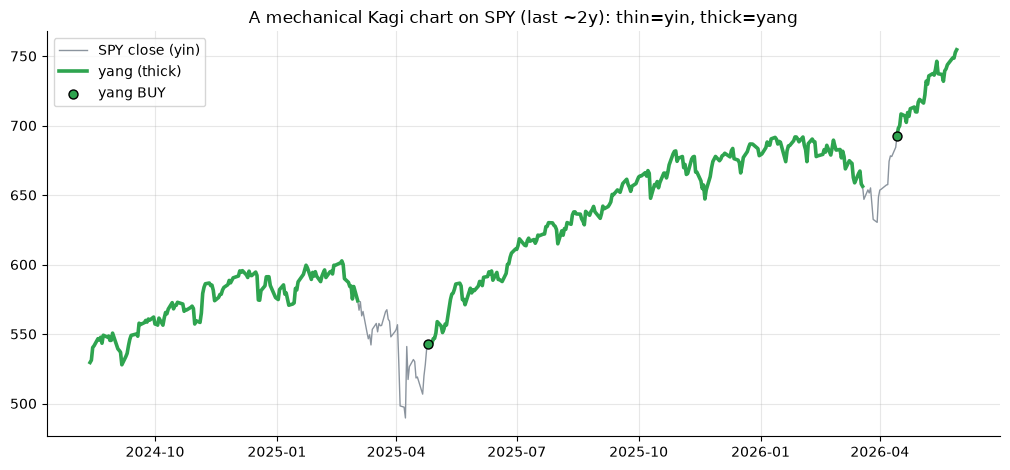

yang switches in window: 2


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    kl = st.kagi_line(cl, reversal=R['reversal'])
    klseg = kl.reindex(seg.index)
    ent = st.yang_switch_entries(cl, reversal=R['reversal'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    thick = klseg['thick'].to_numpy()
    # plot yin segments thin/grey, yang segments thick/green
    ax.plot(seg.index, seg.values, c=GREY, lw=1.0, label='SPY close (yin)')
    yangmask = np.where(thick, seg.values, np.nan)
    ax.plot(seg.index, yangmask, c=GREEN, lw=2.6, label='yang (thick)')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=42, zorder=5, edgecolor='k', label='yang BUY')
    ax.set_title('A mechanical Kagi chart on SPY (last ~2y): thin=yin, thick=yang')
    ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('yang switches in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The thick green stretches sit on the up-legs — *as a description*. The question is whether those green buy dots are followed by gains beyond what any day would give. **Let's race the yang switch against random entries** at four horizons. Blue = buy the yang switch; grey = buy on random days.

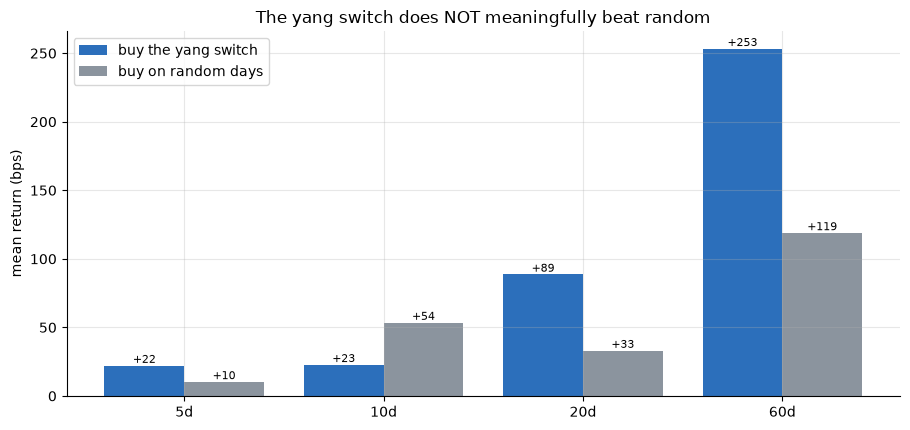

yang: [22, 23, 89, 253]
random: [10, 54, 33, 119]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    sw, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.yang_switch_entries(c, reversal=R['reversal'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        sw.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    sw = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, sw, .4, color='#2c6fbb', label='buy the yang switch')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(sw,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The yang switch does NOT meaningfully beat random'); ax.legend()
plt.tight_layout(); plt.show()
print('yang:', [round(v) for v in sw]); print('random:', [round(v) for v in rnd])

There's the story. The yang switch makes money in absolute terms (**+89 bps** over 20 days) — but the gap over random is small and noisy, and at 10 days the switch is actually *behind* random (**23** vs **54** bps). The quants notebook shows the switch-vs-random *t* never clears 2. The apparent edge is **the market's upward drift**, not the thickness.

**One more sanity check.** What if we re-draw the Kagi with a *different reversal size* — a 1%, 3%, 7% Kagi instead of 4%? Each is an equally legitimate Kagi. If price really 'respects the yang switch', the real 4% line should stand out from the crowd of re-parameterised ones.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.threshold_scramble_placebo(c, 20, reversal=R['reversal'], n_draws=200, seed=495)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real 4% Kagi yang switch (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *re-parameterised* Kagis do at least as well (p={pval:.2f}).')
print('=> the specific reversal/geometry is not doing the work.')

real 4% Kagi yang switch (SPY, 20d): +117.2 bps
... but 55% of *re-parameterised* Kagis do at least as well (p=0.55).
=> the specific reversal/geometry is not doing the work.


More than half of the **re-parameterised** Kagis match or beat the real 4% one (*p* = 0.55). If price genuinely respected *this specific* Kagi, a random reversal would collapse the result. It doesn't — because the result was never about the shoulders and waists.

## 5 · The verdict

- **Signal — None.** The yang-switch buy does **not** beat buying on random days (it's *worse* at 10 days; the switch-vs-random difference never clears *t* = 2). The decent absolute returns are the market's drift, not the line.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs (plus sitting out on yin) only make it worse.
- **"Do Kagi reversals time the market"? — Busted.** Re-draw the Kagi with a different reversal and the result barely moves. The thickness doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The yang switch's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The Kagi rule is long *less* of the time (it steps aside on yin) and pays costs on every flip, so it's a worse, more expensive way to be long. As a forecasting tool, it doesn't pay; as a noise filter, it was never meant to be a strategy.

## 7 · Going further 🚪

- **Other reversal definitions.** Try an ATR-based reversal or point-amount Kagi — the result is robust: drift in, thick line out (the placebo already sweeps reversal sizes).
- **The yin short.** Going short on yin just shorts the drift — a guaranteed way to lose on an up-trending tape; a fun follow-up shows the symmetric failure.
- **A real positive control.** The quants notebook plants a *genuine* post-yang momentum burst into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the yang switch forecasts? Show it beating random entries at **t ≥ 2** on a real tape — then we'll talk.*